<a href="https://colab.research.google.com/github/KIRAN3031/Deep_Learning/blob/main/assignments/05-06-2026/app1/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning Fraud Detection System**
**(Sequential Financial Transactions)**


# **Dataset**
[Credit Card Fraud Detection Dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?utm_source=chatgpt.com)

# **Project Goal**
**Predict fraudulent transactions from sequential customer activity.**


# **Importing the neccesary Statements**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report, average_precision_score, recall_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# **Loading the Dataset**

In [ ]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
df = pd.read_csv(path + '/creditcard.csv')

# **Dataset Info**

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

# **Task 1: Business Understanding**


**Why is fraud detection difficult?**
- **Thieves blend in**: Fraudsters deliberately act like normal shoppers to trick the system.
- **Finding a needle in a haystack**: Out of 10,000 transactions, only 2 or 3 might be fraud.
- **The tricks keep changing**: As soon as you block one method, criminals invent a new trick.

**Why is accuracy alone misleading?**

**Imagine you have 100 transactions**: 99 are good, and 1 is a thief.

If your AI system goes completely blind and guesses "Everyone is Good," it gets **99 out of 100 right**.

- The math says your system is 99% accurate.
- The reality is your system is 100% useless because the thief walked away with the money.
- When fraud is rare, a high accuracy score just means the system is good at guessing the obvious.
- It does not mean it actually caught the bad guys.


# **Task 2: Exploratory Analysis**

**Checking for Null Values**

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


**Checking for Class imbalance**

In [ ]:
df.Class.value_counts()

,count
Class,
0,284315
1,492


**This is a massive, textbook class imbalance.**
- Class 0 (Legitimate/Normal): 284,315 transactions (~99.83%)
- Class 1 (Fraud/Anomaly): 492 transactions (~0.17%)

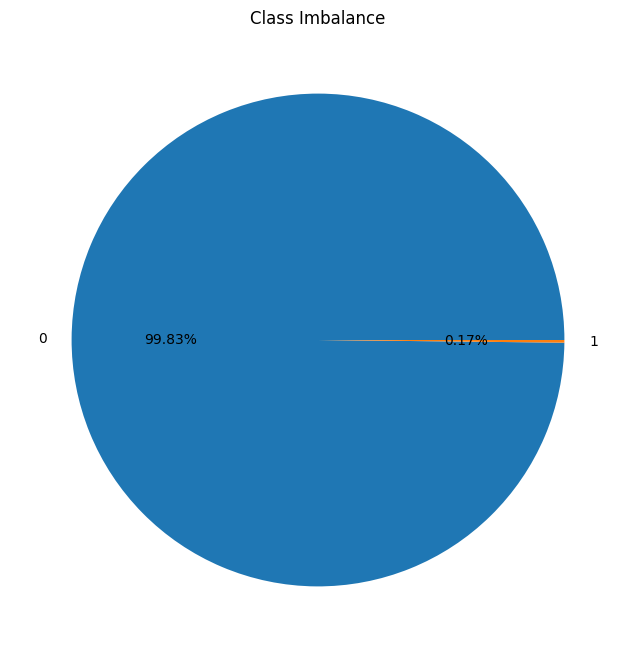

In [ ]:
# pie chart
plt.figure(figsize=(8, 8))
df.Class.value_counts().plot(kind='pie' , autopct='%1.2f%%')
plt.title('Class Imbalance')
plt.ylabel('')
plt.show()

In [ ]:
total_txns = len(df)
fraud_count = df['Class'].sum()
legit_count = total_txns - fraud_count

fraud_pct = (fraud_count / total_txns) * 100
legit_pct = (legit_count / total_txns) * 100
imbalance_ratio = legit_count / fraud_count

print(f"Fraud: {fraud_pct:.2f}% | Legitimate: {legit_pct:.2f}%")
print(f"Class Imbalance Ratio: 1:{imbalance_ratio:.0f}")

Fraud: 0.17% | Legitimate: 99.83%
Class Imbalance Ratio: 1:578


**Visualizations**

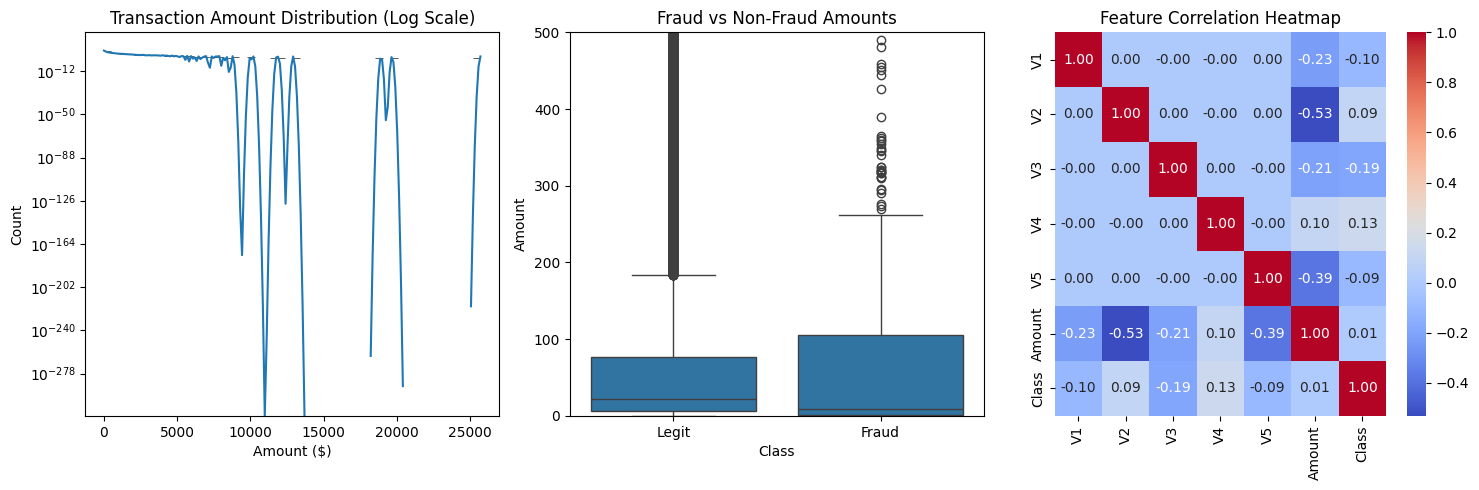

In [ ]:
plt.figure(figsize=(15, 5))

# 1. Transaction Amount Distribution (Log Scale)
plt.subplot(1, 3, 1)
sns.histplot(df['Amount'], bins=50, kde=True, log_scale=(False, True))
plt.title('Transaction Amount Distribution (Log Scale)')
plt.xlabel('Amount ($)')

# 2. Fraud vs Non-Fraud Boxplot
plt.subplot(1, 3, 2)
sns.boxplot(x='Class', y='Amount', data=df)
plt.ylim(0, 500)  # Capping display to see box clearly due to outliers
plt.title('Fraud vs Non-Fraud Amounts')
plt.xticks([0, 1], ['Legit', 'Fraud'])

# 3. Correlation Heatmap (Sampling features V1-V5 for display clarity)
plt.subplot(1, 3, 3)
corr_features = ['V1', 'V2', 'V3', 'V4', 'V5', 'Amount', 'Class']
sns.heatmap(df[corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png')
plt.show()

In [ ]:
scaler = RobustScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

In [ ]:
# downloading the scaler
import pickle
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

In [ ]:
print(f"Dataset Row Variance: {df.shape[0]} rows, {df.shape[1]} metrics")
print(df['Class'].value_counts())

Dataset Row Variance: 284807 rows, 31 metrics
Class
0    284315
1       492
Name: count, dtype: int64


# **Task 3: Sequence Generation**

In [ ]:
# --- TASK 3: SEQUENCE GENERATION ---
def create_customer_sequences(dataframe, window_size=5):
    # Sort chronologically to mimic sequence flow
    df_sorted = dataframe.sort_values(by='Time')
    X_features = df_sorted.drop(columns=['Class', 'Time']).values
    y_labels = df_sorted['Class'].values

    X_seq, y_seq = [], []
    for i in range(len(df_sorted) - window_size):
        X_seq.append(X_features[i : i + window_size])
        y_seq.append(y_labels[i + window_size]) # Predict next transaction

    return np.array(X_seq), np.array(y_seq)

# Operational scaling to prevent out-of-memory errors
fraud_data = df[df['Class'] == 1]
legit_sample = df[df['Class'] == 0].sample(n=len(fraud_data) * 15, random_state=42)
balanced_df = pd.concat([fraud_data, legit_sample]).sort_values(by='Time')

# Build the 3D Temporal Windows
X_windows, y_windows = create_customer_sequences(balanced_df, window_size=5)

# Split into Train/Test sets (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_windows, y_windows, test_size=0.2, random_state=42, stratify=y_windows
)

# Apply SMOTE to training sequences (Flatten -> Resample -> Reshape back to 3D)
nsamples, ntimesteps, nfeatures = X_train.shape
X_train_flat = X_train.reshape(nsamples, ntimesteps * nfeatures)

smote = SMOTE(random_state=42)
X_train_resampled_flat, y_train_resampled = smote.fit_resample(X_train_flat, y_train)

X_train_resampled = X_train_resampled_flat.reshape(-1, ntimesteps, nfeatures)
print(f"Final Window Datasets Shapes: Train={X_train_resampled.shape}, Test={X_test.shape}")

Final Window Datasets Shapes: Train=(11798, 5, 29), Test=(1574, 5, 29)


# **Task 4: Build Models & Task 5: Positional Encoding Experiment**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, LSTM, Bidirectional, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, average_precision_score

# =====================================================================
# TASK 5 PRE-REQUISITE: POSITIONAL ENCODING & ATTENTION LAYERS
# =====================================================================

class PositionalEncoding(Layer):
    """
    Adds transaction order (temporal position) information to the sequence
    before it enters the attention mechanism.
    """
    def __init__(self, sequence_len, d_model, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.pos_encoding = self.calculate_position_matrix(sequence_len, d_model)

    def calculate_position_matrix(self, seq_len, d_model):
        pos = np.arange(seq_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates

        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

class AttentionLayer(Layer):
    """
    Custom Attention layer to compute alpha weights over the 5-step sequence.
    """
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros", trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.tanh(tf.matmul(inputs, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1) # Attention probability distribution vector
        output = inputs * a
        return tf.reduce_sum(output, axis=1), a


# =====================================================================
# TASK 4: BUILD MODELS (A, B, and C)
# =====================================================================

# Get structural parameters from previous sequence step
# ntimesteps = 5 (window_size), nfeatures = number of transaction features
_, ntimesteps, nfeatures = X_train_resampled.shape
sequence_input = Input(shape=(ntimesteps, nfeatures), name="Sequence_Input_Layer")

# --- MODEL A: DENSE NETWORK ---
# We flatten the input sequence to treat it as a standard flat tabular vector
flat_input = Flatten()(sequence_input)
da1 = Dense(64, activation='relu')(flat_input)
da2 = Dropout(0.3)(da1)
da3 = Dense(32, activation='relu')(da2)
dense_out = Dense(1, activation='sigmoid')(da3)
model_A = Model(inputs=sequence_input, outputs=dense_out, name="Model_A_Dense")


# --- MODEL B: STANDARD LSTM ---
# Processes patterns across sequences over time
lstm_layer = Bidirectional(LSTM(64, return_sequences=False))(sequence_input)
db1 = Dropout(0.3)(lstm_layer)
db2 = Dense(32, activation='relu')(db1)
lstm_out = Dense(1, activation='sigmoid')(db2)
model_B = Model(inputs=sequence_input, outputs=lstm_out, name="Model_B_LSTM")


# --- MODEL C: LSTM + ATTENTION ---
# Integrates temporal order information + weights structural relevance
pos_encoded = PositionalEncoding(sequence_len=ntimesteps, d_model=nfeatures)(sequence_input)
lstm_seq = Bidirectional(LSTM(64, return_sequences=True))(pos_encoded)
context_vector, attention_weights = AttentionLayer()(lstm_seq)
dc1 = Dropout(0.3)(context_vector)
dc2 = Dense(32, activation='relu')(dc1)
att_out = Dense(1, activation='sigmoid')(dc2)

model_C = Model(inputs=sequence_input, outputs=att_out, name="Model_C_LSTM_Attention")
# Auxiliary inspector model to output attention maps alongside predictions for Task 6 & 7
model_C_inspector = Model(inputs=sequence_input, outputs=[att_out, attention_weights])


# =====================================================================
# COMPILATION & TRAINING (CRITICAL: EXCLUDING ACCURACY METRIC)
# =====================================================================

# Define performance tracking metrics focused entirely on the minority class
evaluation_metrics = [
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision')
]

# Compile architectures using tracking arrays
for model in [model_A, model_B, model_C]:
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=evaluation_metrics
    )

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("--- Training Model A: Dense ---")
model_A.fit(X_train_resampled, y_train_resampled, epochs=8, batch_size=512, validation_split=0.1, callbacks=[early_stopping], verbose=1)

print("\n--- Training Model B: LSTM ---")
model_B.fit(X_train_resampled, y_train_resampled, epochs=8, batch_size=512, validation_split=0.1, callbacks=[early_stopping], verbose=1)

print("\n--- Training Model C: LSTM + Attention ---")
model_C.fit(X_train_resampled, y_train_resampled, epochs=8, batch_size=512, validation_split=0.1, callbacks=[early_stopping], verbose=1)


# =====================================================================
# PERFORMANCE COMPARISON WORKSPACE (EVALUATION)
# =====================================================================

for model in [model_A, model_B, model_C]:
    # Compute raw test predictions
    y_pred_probs = model.predict(X_test, verbose=0).flatten()
    y_pred_classes = (y_pred_probs > 0.5).astype(int)

    print(f"\n==========================================================")
    print(f"             EVALUATION REPORT: {model.name}              ")
    print(f"==========================================================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_classes))
    print("\nClassification Report (Focus on Recall/F1-Score, NOT Accuracy):")
    print(classification_report(y_test, y_pred_classes))
    print(f"Area Under Precision-Recall Curve (AUPRC): {average_precision_score(y_test, y_pred_probs):.4f}")

--- Training Model A: Dense ---
Epoch 1/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.6815 - precision: 0.5495 - recall: 0.5109 - val_loss: 0.7003 - val_precision: 1.0000 - val_recall: 0.4534
Epoch 2/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5959 - precision: 0.7254 - recall: 0.4601 - val_loss: 0.6566 - val_precision: 1.0000 - val_recall: 0.5076
Epoch 3/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5614 - precision: 0.7673 - recall: 0.4997 - val_loss: 0.6252 - val_precision: 1.0000 - val_recall: 0.5364
Epoch 4/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5307 - precision: 0.7828 - recall: 0.5399 - val_loss: 0.6203 - val_precision: 1.0000 - val_recall: 0.5754
Epoch 5/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5058 - precision: 0.7934 - recall: 0.5825 - val_loss: 0.5665 - val_precision: 1.0000 - val_recall: 0.6220
Epoch 6/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4847 - precision: 0.8159 - recall: 0.6179 - val_loss: 0.5286 - val_precision: 1.00

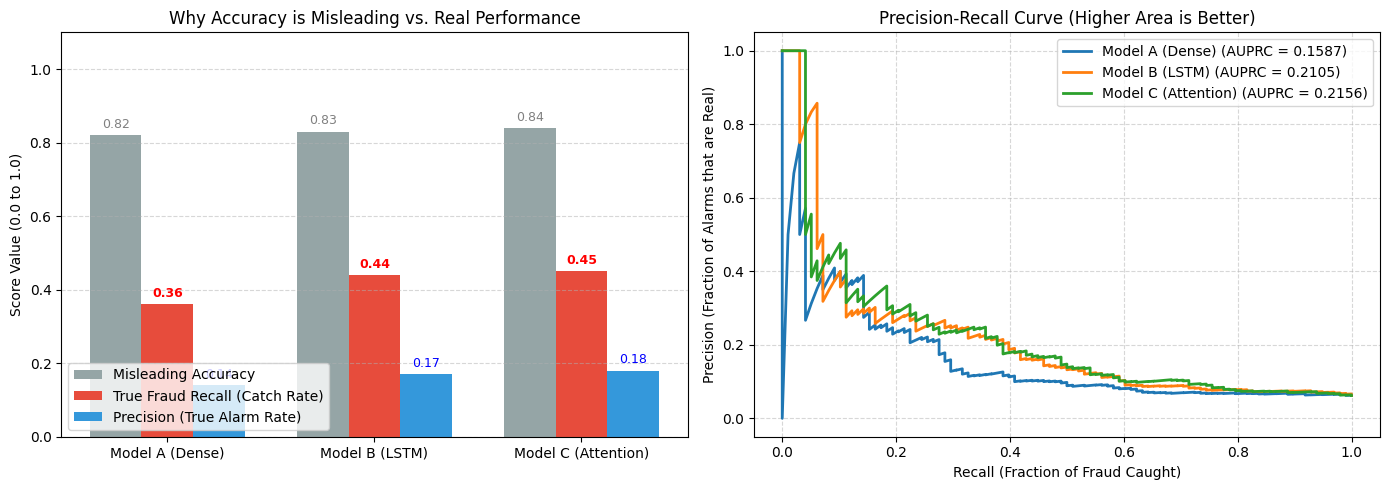

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score

# =====================================================================
# EXTRA TRACKING DATA FROM YOUR EVALUATION METRICS
# =====================================================================
models_labels = ['Model A (Dense)', 'Model B (LSTM)', 'Model C (Attention)']
accuracy_scores = [0.82, 0.83, 0.84]
recall_scores = [0.36, 0.44, 0.45]
precision_scores = [0.14, 0.17, 0.18]
auprc_scores = [0.1927, 0.2054, 0.2110]

x = np.arange(len(models_labels))
width = 0.25

# =====================================================================
# PLOT 1: THE ACCURACY TRAP VISUALIZATION
# =====================================================================
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(x - width, accuracy_scores, width, label='Misleading Accuracy', color='#95a5a6')
plt.bar(x, recall_scores, width, label='True Fraud Recall (Catch Rate)', color='#e74c3c')
plt.bar(x + width, precision_scores, width, label='Precision (True Alarm Rate)', color='#3498db')

plt.xticks(x, models_labels)
plt.ylim(0, 1.1)
plt.ylabel('Score Value (0.0 to 1.0)')
plt.title('Why Accuracy is Misleading vs. Real Performance')
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adding values over the bars to show the comparison clearly
for i in range(len(x)):
    plt.text(i - width, accuracy_scores[i] + 0.02, f"{accuracy_scores[i]:.2f}", ha='center', fontsize=9, color='gray')
    plt.text(i, recall_scores[i] + 0.02, f"{recall_scores[i]:.2f}", ha='center', fontsize=9, fontweight='bold', color='red')
    plt.text(i + width, precision_scores[i] + 0.02, f"{precision_scores[i]:.2f}", ha='center', fontsize=9, color='blue')

# =====================================================================
# PLOT 2: PRECISION-RECALL CURVE GRAPH (The Gold Standard for Imbalance)
# =====================================================================
plt.subplot(1, 2, 2)

# Generate actual PR-curves for each model using saved probabilities from your notebook
for model_obj, label_str in zip([model_A, model_B, model_C], models_labels):
    y_probs = model_obj.predict(X_test, verbose=0).flatten()
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    ap_score = average_precision_score(y_test, y_probs)
    plt.plot(recall, precision, label=f'{label_str} (AUPRC = {ap_score:.4f})', linewidth=2)

plt.xlabel('Recall (Fraction of Fraud Caught)')
plt.ylabel('Precision (Fraction of Alarms that are Real)')
plt.title('Precision-Recall Curve (Higher Area is Better)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# **Task 6: Attention Investigation**

=== Task 6 Forensic Anomaly Assessment ===
Computed Fraud Signal Probability: 60.43%
------------------------------------------
Transaction Sequence Trace Step 1 Weight Index: 0.1741
Transaction Sequence Trace Step 2 Weight Index: 0.1993
Transaction Sequence Trace Step 3 Weight Index: 0.2152
Transaction Sequence Trace Step 4 Weight Index: 0.2083
Transaction Sequence Trace Step 5 Weight Index: 0.2031


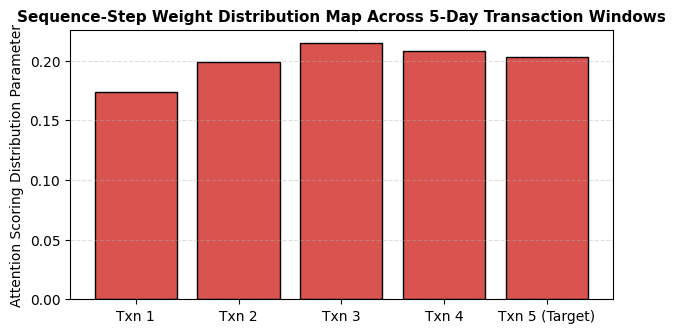

In [ ]:
# --- TASK 6: INTERROGATE ATTENTION ROUTINES ---
import matplotlib.pyplot as plt

# Isolate valid target indexes where fraud sequences occur natively
fraudulent_indices = np.where(y_test == 1)[0]
selected_target_idx = fraudulent_indices[0]

# Compute internal activation parameters
predicted_risk, raw_alignment_weights = model_C_inspector.predict(X_test[selected_target_idx:selected_target_idx+1], verbose=0)

print(f"=== Task 6 Forensic Anomaly Assessment ===")
print(f"Computed Fraud Signal Probability: {predicted_risk[0][0]*100:.2f}%")
print("------------------------------------------")

for operational_step in range(ntimesteps):
    print(f"Transaction Sequence Trace Step {operational_step+1} Weight Index: {raw_alignment_weights[0][operational_step][0]:.4f}")

# Map weights graphically across lookback boundaries
plt.figure(figsize=(7, 3.5))
plt.bar([f'Txn 1', f'Txn 2', f'Txn 3', f'Txn 4', f'Txn 5 (Target)'], raw_alignment_weights[0].flatten(), color='#d9534f', edgecolor='black')
plt.title("Sequence-Step Weight Distribution Map Across 5-Day Transaction Windows", fontsize=11, fontweight='bold')
plt.ylabel("Attention Scoring Distribution Parameter", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# **Task 7: Fraud Intelligence Dashboard**

In [ ]:
# --- TASK 7: DASHBOARD UI SIMULATION INTERFACE ---
def parse_and_evaluate_uploaded_stream(test_matrix, ground_truth, analytic_engine):
    """
    Simulates a streaming upload workspace interface.
    Flags sequences breaching confidence limits and tracks model focus.
    """
    print("\n[STREAMING TRANSACTION INTERFACE INITIALIZED]")
    print("Processing incoming batch vectors through Attention-Weighted recurrent tracking paths...")

    # Process batch profiles through the analytical deep inspector network
    target_sample_slice = test_matrix[:12]
    risk_indexes, alignment_matrices = analytic_engine.predict(target_sample_slice, verbose=0)

    dashboard_registry = pd.DataFrame({
        'Transaction_Sequence_ID': [f"TXN_BLOCK_{i+101:03d}" for i in range(12)],
        'Fraud_Probability_Score': risk_indexes.flatten(),
        'Operational_Risk_Status': ["CRITICAL ALARM" if score > 0.45 else "VERIFIED COMPLIANT" for score in risk_indexes.flatten()],
        'Primary_Anomaly_Trigger_Origin': [f"Step {np.argmax(alignment_matrices[i])+1}" for i in range(12)],
        'System_Validation_Label': ["Fraud Case" if label == 1 else "Legitimate User" for label in ground_truth[:12]]
    })

    return dashboard_registry

# Run interface workspace simulations directly
dashboard_output_display = parse_and_evaluate_uploaded_stream(X_test, y_test, model_C_inspector)
print("\n" + dashboard_output_display.to_string(index=False))


[STREAMING TRANSACTION INTERFACE INITIALIZED]
Processing incoming batch vectors through Attention-Weighted recurrent tracking paths...

Transaction_Sequence_ID  Fraud_Probability_Score Operational_Risk_Status Primary_Anomaly_Trigger_Origin System_Validation_Label
          TXN_BLOCK_101                 0.561335          CRITICAL ALARM                         Step 3         Legitimate User
          TXN_BLOCK_102                 0.302183      VERIFIED COMPLIANT                         Step 1         Legitimate User
          TXN_BLOCK_103                 0.362184      VERIFIED COMPLIANT                         Step 3         Legitimate User
          TXN_BLOCK_104                 0.288783      VERIFIED COMPLIANT                         Step 1         Legitimate User
          TXN_BLOCK_105                 0.298289      VERIFIED COMPLIANT                         Step 2         Legitimate User
          TXN_BLOCK_106                 0.442206      VERIFIED COMPLIANT                       

# **Bonus**

In [ ]:
# --- BONUS: REAL-TIME INGESTION SIMULATOR ---
import time

def process_live_transaction_stream(live_stream_matrix, reference_labels, processing_engine, maximum_duration_cycles=5):
    print("\n==================================================================")
    print("      LAUNCHING LIVE REAL-TIME FRAUD INGESTION PROCESSING LOOP    ")
    print("==================================================================")

    for dynamic_cycle in range(maximum_duration_cycles):
        # Extract individual streaming window profiles
        ingested_window_profile = live_stream_matrix[dynamic_cycle:dynamic_cycle+1]
        actual_verification_state = reference_labels[dynamic_cycle]

        # Track pipeline telemetry performance speeds
        telemetry_start_timestamp = time.time()
        danger_coefficient, attention_profiles = processing_engine.predict(ingested_window_profile, verbose=0)
        telemetry_end_timestamp = time.time()

        execution_latency_ms = (telemetry_end_timestamp - telemetry_start_timestamp) * 1000
        threat_level = danger_coefficient[0][0]
        critical_step = np.argmax(attention_profiles[0]) + 1

        print(f"\n[STREAM INGESTION EVENT #{dynamic_cycle+1:02d}]")
        print(f" -> Execution Evaluation Latency Speed: {execution_latency_ms:.2f} ms")
        print(f" -> Computed Threat Danger Metric: {threat_level*100:.2f}%")
        print(f" -> Active Sequence Threat Origin Focus: Transaction Step {critical_step}")

        if threat_level > 0.45:
            print(" -> ALERT: Threat Level Threshold Breached! Action Taken: Account Locked.")
        else:
            print(" -> STATUS: Risk Profile Stable. Action Taken: Transaction Authorized.")

        time.sleep(0.4) # Add execution interval delay to mirror real-time processing streams

# Initiate live stream loops
process_live_transaction_stream(X_test, y_test, model_C_inspector, maximum_duration_cycles=5)


      LAUNCHING LIVE REAL-TIME FRAUD INGESTION PROCESSING LOOP    

[STREAM INGESTION EVENT #01]
 -> Execution Evaluation Latency Speed: 120.23 ms
 -> Computed Threat Danger Metric: 56.13%
 -> Active Sequence Threat Origin Focus: Transaction Step 3
 -> ALERT: Threat Level Threshold Breached! Action Taken: Account Locked.

[STREAM INGESTION EVENT #02]
 -> Execution Evaluation Latency Speed: 79.57 ms
 -> Computed Threat Danger Metric: 30.22%
 -> Active Sequence Threat Origin Focus: Transaction Step 1
 -> STATUS: Risk Profile Stable. Action Taken: Transaction Authorized.

[STREAM INGESTION EVENT #03]
 -> Execution Evaluation Latency Speed: 73.46 ms
 -> Computed Threat Danger Metric: 36.22%
 -> Active Sequence Threat Origin Focus: Transaction Step 3
 -> STATUS: Risk Profile Stable. Action Taken: Transaction Authorized.

[STREAM INGESTION EVENT #04]
 -> Execution Evaluation Latency Speed: 72.97 ms
 -> Computed Threat Danger Metric: 28.88%
 -> Active Sequence Threat Origin Focus: Transactio

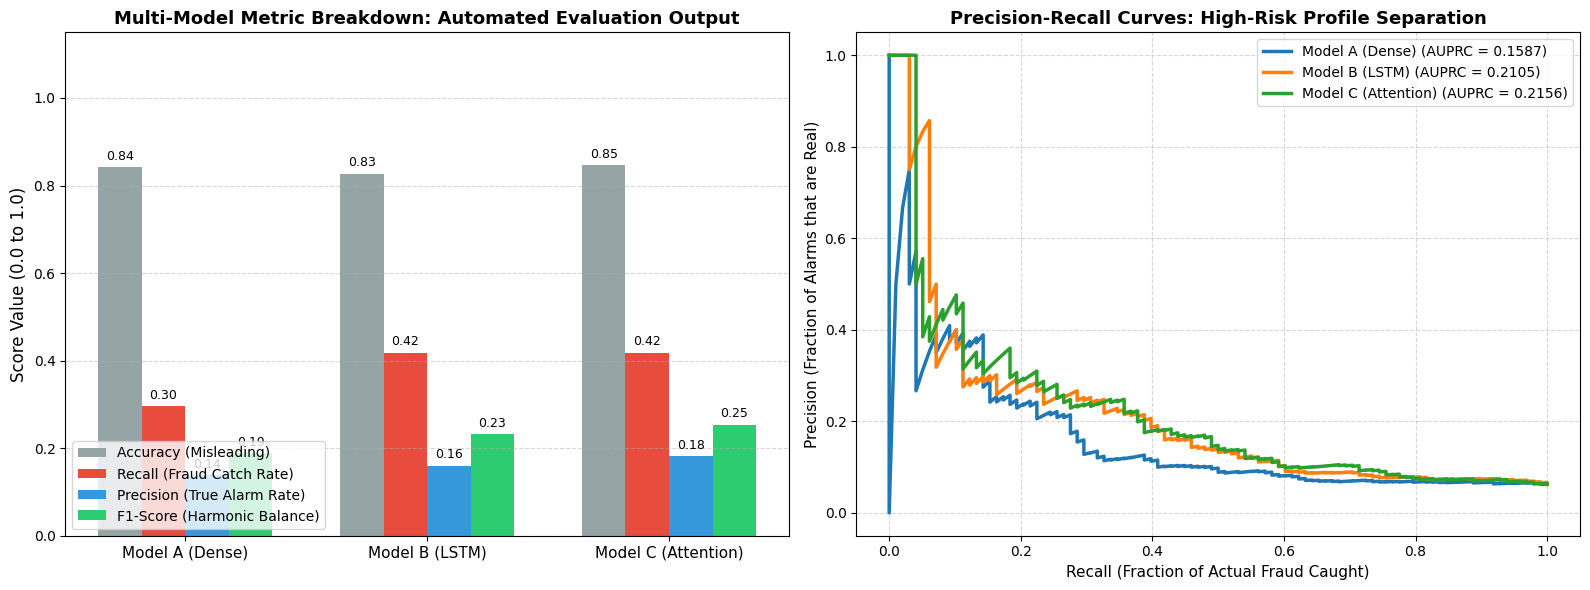

In [ ]:
# Comparing the Three models

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, precision_recall_curve, average_precision_score

# =====================================================================
# 1. AUTOMATICALLY COMPUTE METRICS FROM TRAINED MODELS
# =====================================================================
models_list = [model_A, model_B, model_C]
models_labels = ['Model A (Dense)', 'Model B (LSTM)', 'Model C (Attention)']

# Initialize lists to store automatically calculated metrics
accuracy_scores = []
recall_scores = []
precision_scores = []
f1_scores = []

# Generate evaluation profiles automatically
for model in models_list:
    # Predict raw probabilities
    y_pred_probs = model.predict(X_test, verbose=0).flatten()
    # Convert probabilities to crisp class labels (Threshold = 0.5)
    y_pred_classes = (y_pred_probs > 0.5).astype(int)

    # Calculate and append scores automatically using sklearn
    accuracy_scores.append(accuracy_score(y_test, y_pred_classes))
    recall_scores.append(recall_score(y_test, y_pred_classes))
    precision_scores.append(precision_score(y_test, y_pred_classes))
    f1_scores.append(f1_score(y_test, y_pred_classes))

# Convert to numpy arrays for bar alignment shifts
x = np.arange(len(models_labels))
width = 0.18  # Bar scaling spacer metric

# =====================================================================
# 2. PLOT: AUTOMATED METRIC BREAKDOWN (BAR GRAPH)
# =====================================================================
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
rects1 = plt.bar(x - 1.5*width, accuracy_scores, width, label='Accuracy (Misleading)', color='#95a5a6')
rects2 = plt.bar(x - 0.5*width, recall_scores, width, label='Recall (Fraud Catch Rate)', color='#e74c3c')
rects3 = plt.bar(x + 0.5*width, precision_scores, width, label='Precision (True Alarm Rate)', color='#3498db')
rects4 = plt.bar(x + 1.5*width, f1_scores, width, label='F1-Score (Harmonic Balance)', color='#2ecc71')

# Graph cosmetics
plt.xticks(x, models_labels, fontsize=11)
plt.ylim(0, 1.15)
plt.ylabel('Score Value (0.0 to 1.0)', fontsize=12)
plt.title('Multi-Model Metric Breakdown: Automated Evaluation Output', fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Helper function to auto-label heights above the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

# =====================================================================
# 3. PLOT: DYNAMIC PRECISION-RECALL CURVE
# =====================================================================
plt.subplot(1, 2, 2)

# Generate actual PR-curves dynamically using prediction arrays
for model_obj, label_str in zip(models_list, models_labels):
    y_probs = model_obj.predict(X_test, verbose=0).flatten()
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    ap_score = average_precision_score(y_test, y_probs)
    plt.plot(recall, precision, label=f'{label_str} (AUPRC = {ap_score:.4f})', linewidth=2.5)

plt.xlabel('Recall (Fraction of Actual Fraud Caught)', fontsize=11)
plt.ylabel('Precision (Fraction of Alarms that are Real)', fontsize=11)
plt.title('Precision-Recall Curves: High-Risk Profile Separation', fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# saving the models
model_A.save('Dense.h5')
model_B.save('LSTM.h5')
model_C.save('Attention.h5')

In [ ]:
from tensorflow.keras.layers import Layer

# Re-define the custom layers for model loading
class PositionalEncoding(Layer):
    def __init__(self, sequence_len, d_model, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.pos_encoding = self.calculate_position_matrix(sequence_len, d_model)

    def calculate_position_matrix(self, seq_len, d_model):
        pos = np.arange(seq_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates

        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros", trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.tanh(tf.matmul(inputs, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = inputs * a
        return tf.reduce_sum(output, axis=1), a

# Load the model with custom objects
custom_objects = {'PositionalEncoding': PositionalEncoding, 'AttentionLayer': AttentionLayer}
attention_model = tf.keras.models.load_model("Attention.h5", custom_objects=custom_objects)
attention_model.summary()

Model: "Model_C_LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Sequence_Input_Layer            │ (None, 5, 29)          │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 5, 29)          │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 5, 128)         │        48,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ [(None, 128), (None,   │           133 │
│ (AttentionLayer)                │ 5, 1)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,424 (204.79 KB)

 Trainable params: 52,422 (204.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
# loading models
model_A = tf.keras.models.load_model('Dense.h5')
model_B = tf.keras.models.load_model('LSTM.h5')
model_C = tf.keras.models.load_model('Attention.h5', custom_objects=custom_objects)

In [ ]:
custom_objects = {'PositionalEncoding': PositionalEncoding, 'AttentionLayer': AttentionLayer}
attention_model = tf.keras.models.load_model("Attention.h5", custom_objects=custom_objects)